# Making animations using matplotlib's FuncAnimation

*CU Boulder GEOL 3600 Introduction to Python Programming, Nov 2025*

### Goal: learn to use FuncAnimation to create and save animations

## Overview

- Animations can be powerful ways of visualizing and communicating data and models

- An animation is just a sequence of still images that are played in sequence

- Lots of ways to create animations in Python

- The one we're exploring today is `FuncAnimation`

## How `FuncAnimation` works

1. Create an initial matplotlib plot using `subplots()`, and save the `figure` object that it returns.

2. Write a function that updates your plot, creating one frame for your animation. The function should take the frame number (an integer) as an argument.

3. Call `FuncAnimation()`, passing it your `figure` object and your function. It returns an `animation` object.

4. To play the animation in a notebook, convert it to an HTML object.

`FuncAnimation()` will actually call your own function, once per frame. This is an example of a programming concept called a **callback function**. It illustrates that in Python a function is also a variable that can be passed as an argument to another function. (Similar functionality exists in other programming languages; for example, C has "function pointers".)


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

### MPL `Figure` and `Axis` objects and the `subplots()` function

Matplotlib makes extensive use of object-oriented programming, and we can take advantage of the classes and objects that it offers.

Two such classes are `Figure` and `Axis`.

- You can think of a `Figure` as the window or canvas that contains all your plots. A `Figure` object can contain multiple `Axes` objects.
- An `Axes` object represents one graph, together with its axes, labels



In [2]:
print(plt.Figure.__doc__)

The top level container for all the plot elements.

See `matplotlib.figure` for an index of class methods.

Attributes
----------
patch
    The `.Rectangle` instance representing the figure background patch.

suppressComposite
    For multiple images, the figure will make composite images
    depending on the renderer option_image_nocomposite function.  If
    *suppressComposite* is a boolean, this will override the renderer.


In [3]:
print(plt.Axes.__doc__)

An Axes object encapsulates all the elements of an individual (sub-)plot in
a figure.

It contains most of the (sub-)plot elements: `~.axis.Axis`,
`~.axis.Tick`, `~.lines.Line2D`, `~.text.Text`, `~.patches.Polygon`, etc.,
and sets the coordinate system.

Like all visible elements in a figure, Axes is an `.Artist` subclass.

The `Axes` instance supports callbacks through a callbacks attribute which
is a `~.cbook.CallbackRegistry` instance.  The events you can connect to
are 'xlim_changed' and 'ylim_changed' and the callback will be called with
func(*ax*) where *ax* is the `Axes` instance.

.. note::

    As a user, you do not instantiate Axes directly, but use Axes creation
    methods instead; e.g. from `.pyplot` or `.Figure`:
    `~.pyplot.subplots`, `~.pyplot.subplot_mosaic` or `.Figure.add_axes`.

Attributes
----------
dataLim : `.Bbox`
    The bounding box enclosing all data displayed in the Axes.
viewLim : `.Bbox`
    The view limits in data coordinates.


One way to access a `Figure` and one or more `Axes` objects is to use the `subplots()` function. By default, this function will create and return a blank (empty) `Figure` object that contains one empty `Axes` object.

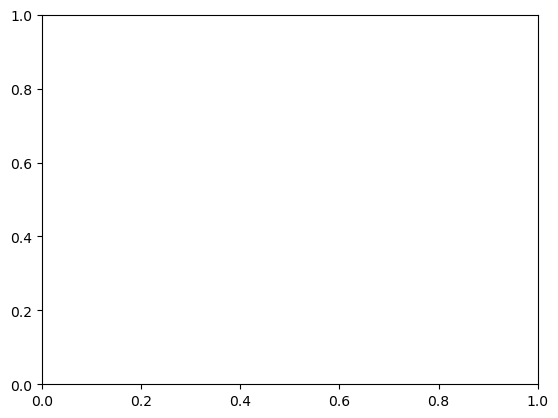

In [4]:
myfig, myax = plt.subplots()

The Python `vars()` function displays the editable attributes of a Python object. Running it on the newly created `myfig` object reveals that it has lots of these!

In [5]:
vars(myfig)

{'_stale': True,
 'stale_callback': None,
 'figure': <Figure size 640x480 with 1 Axes>,
 '_transform': None,
 '_transformSet': False,
 '_visible': True,
 '_animated': False,
 '_alpha': None,
 'clipbox': None,
 '_clippath': None,
 '_clipon': True,
 '_label': '',
 '_picker': None,
 '_rasterized': False,
 '_agg_filter': None,
 '_mouseover': False,
 '_callbacks': <matplotlib.cbook.CallbackRegistry at 0x11077e600>,
 '_remove_method': None,
 '_url': None,
 '_gid': None,
 '_snap': None,
 '_sketch': None,
 '_path_effects': [],
 '_sticky_edges': _XYPair(x=[], y=[]),
 '_in_layout': True,
 '_suptitle': None,
 '_supxlabel': None,
 '_supylabel': None,
 '_align_label_groups': {'x': <matplotlib.cbook.Grouper at 0x110ed5df0>,
  'y': <matplotlib.cbook.Grouper at 0x110ed5eb0>,
  'title': <matplotlib.cbook.Grouper at 0x10e79c260>},
 '_localaxes': [<Axes: >],
 'artists': [],
 'lines': [],
 'patches': [],
 'texts': [],
 'images': [],
 'legends': [],
 'subfigs': [],
 'suppressComposite': None,
 '_layout_eng

In general, attributes that begin with an underscaore, like `_dpi`, are meant to be **private**, which means that a user shouldn't interact with them directly, but rather work through the object's **public** methods.

Likewise, we can inspect the attributes of the `myax` object:

In [6]:
vars(myax)

{'_stale': True,
 'stale_callback': <function matplotlib.figure._stale_figure_callback(self, val)>,
 '_axes': <Axes: >,
 'figure': <Figure size 640x480 with 1 Axes>,
 '_transform': None,
 '_transformSet': False,
 '_visible': True,
 '_animated': False,
 '_alpha': None,
 'clipbox': None,
 '_clippath': None,
 '_clipon': True,
 '_label': '',
 '_picker': None,
 '_rasterized': False,
 '_agg_filter': None,
 '_mouseover': False,
 '_callbacks': <matplotlib.cbook.CallbackRegistry at 0x110f00ef0>,
 '_remove_method': <bound method FigureBase.delaxes of <Figure size 640x480 with 1 Axes>>,
 '_url': None,
 '_gid': None,
 '_snap': None,
 '_sketch': None,
 '_path_effects': [],
 '_sticky_edges': _XYPair(x=[], y=[]),
 '_in_layout': True,
 '_position': Bbox([[0.125, 0.10999999999999999], [0.9, 0.88]]),
 '_originalPosition': Bbox([[0.125, 0.10999999999999999], [0.9, 0.88]]),
 '_aspect': 'auto',
 '_adjustable': 'box',
 '_anchor': 'C',
 '_stale_viewlims': {'x': False, 'y': False},
 '_forward_navigation_event

If we want to find out what *methods* are available, the easiest option is just to look up the online documentation.

But just for fun, here's another approach, which happens to use a *list comprehension*:

In [7]:
axes_methods = [method for method in dir(plt.Axes) if callable(getattr(plt.Axes, method))]
axes_methods

['ArtistList',
 '_AxesBase__clear',
 '__class__',
 '__delattr__',
 '__dir__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '_add_text',
 '_check_no_units',
 '_cm_set',
 '_convert_dx',
 '_different_canvas',
 '_errorevery_to_mask',
 '_fill_between_x_or_y',
 '_fully_clipped_to_axes',
 '_gci',
 '_gen_axes_patch',
 '_gen_axes_spines',
 '_get_aspect_ratio',
 '_get_pan_points',
 '_get_view',
 '_init_axis',
 '_internal_update',
 '_label_outer_xaxis',
 '_label_outer_yaxis',
 '_make_twin_axes',
 '_parse_scatter_color_args',
 '_pcolorargs',
 '_prepare_view_from_bbox',
 '_process_unit_info',
 '_quiver_units',
 '_remove_legend',
 '_request_autoscale_view',
 '_sci',
 '_set_alpha_for_array',
 '_set_artist_props',
 '_set_gc_clip',
 '_set_lim_an

(Quiz: how could you remove methods starting with `_` from this list?)

### Example: a moving ball

In this example, we'll animate a ball moving from lower left to upper right.

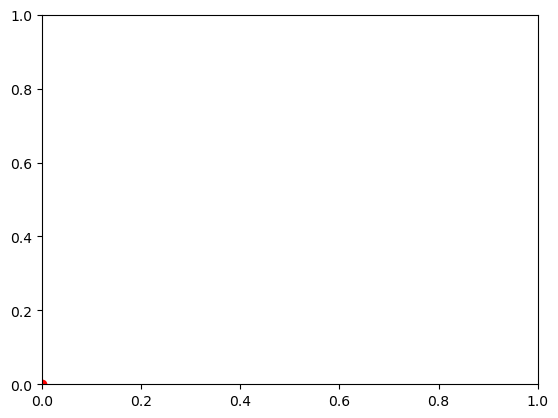

In [8]:
# 1. create a blank figure
fig, ax = plt.subplots()

# 2. define a function to update the plot
def plot_ball(frame_num):
    x = y = frame_num / 10.0
    ax.cla()
    ax.plot(x, y, 'ro')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# 3. Call FuncAnimation
anim = FuncAnimation(fig=fig, func=plot_ball, frames=11)

In [9]:
# 4. Convert the animation to an HTML object
vid = HTML(anim.to_jshtml())
vid

### Try it yourself

- What happens if you comment out the `ax.cla()` ("clear axis") line in `plot_ball()`?

- What happens if you comment out `set_xlim()` or `set_ylim()` calls?

- Try modifying the code to have your ball move from lower left to upper right over 51 iterations instead of 11.

- Try specifying an interval between frames, in milliseconds, using the `FuncAnimation` keyword parameter `interval` (the default is 200 milliseconds).

- Try running `help()` on `FuncAnimation` see what other optional keyword parameters are available.

In [ ]:
# (copy-paste the above code here and then experiment with it)

## Example: animating a timeseries plot

The next example uses the Mauna Loa monthly CO2 records, which we'll start by reading from a text file.

In [10]:
import pandas as pd

# Read Mauna Loa monthly CO2 data
data = pd.read_table("co2_mm_mlo.txt", skiprows=41, header=None, sep=r'\s+')
data.columns = [
    "year",
    "month",
    "decimal date",
    "monthly average",
    "de-seasonalized",
    "# days",
    "std. of days",
    "unc of mon mean",
]
data

,year,month,decimal date,monthly average,de-seasonalized,# days,std. of days,unc of mon mean
0,1958,3,1958.2027,315.70,314.43,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.71,-1,-9.99,-0.99
3,1958,6,1958.4548,317.24,315.14,-1,-9.99,-0.99
4,1958,7,1958.5370,315.86,315.18,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
781,2023,4,2023.2917,423.36,420.69,28,0.60,0.22
782,2023,5,2023.3750,424.00,420.55,31,0.69,0.24
783,2023,6,2023.4583,423.68,421.19,29,0.57,0.20
784,2023,7,2023.5417,421.83,421.42,21,0.48,0.20


Now we'll animate it, using a red circle to denote the current data point, and a blue line to indicate all preceding data. (Here we'll plot every 4th data point to speed up the process and save on memory.)

In [11]:
# Shorthand
decdate = data["decimal date"]
co2 = data["monthly average"]

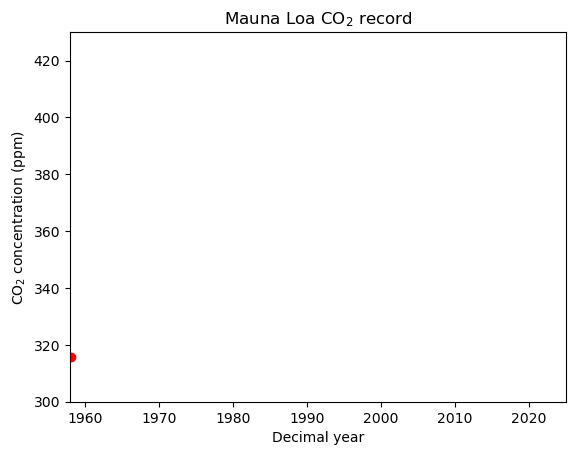

In [12]:
# 1. Create a blank plot
fig, ax = plt.subplots()

# 2. Define function for plotting
def plot_co2(i):
    ax.cla()
    ax.plot(decdate[:(4*i+1)], co2[:(4*i+1)], 'b')
    ax.plot(decdate[4*i], co2[4*i], 'ro')
    ax.set_xlim(1958, 2025)
    ax.set_ylim(300, 430)
    ax.set_xlabel("Decimal year")
    ax.set_ylabel(r"CO$_2$ concentration (ppm)")
    ax.set_title(r"Mauna Loa CO$_2$ record")

# 3. Create a FuncAnimation object
anim = FuncAnimation(fig, plot_co2, len(co2) // 4, interval=60.0)

# 4. Convert to an HTML object
vid = HTML(anim.to_jshtml())

# 5. Play
vid

## Copy versus reference

In [13]:
v = 3.56784

In [14]:
u = v

In [15]:
v = 111.11

In [16]:
v

111.11

In [17]:
u

3.56784

In [18]:
mylist = ['dog', 17, 1.23, True]

In [19]:
mylist

['dog', 17, 1.23, True]

In [20]:
myotherlist = mylist

In [21]:
myotherlist

['dog', 17, 1.23, True]

In [22]:
myotherlist[0] = 'cat'

In [23]:
myotherlist[3] = False

In [24]:
myotherlist[2] = 3.21

In [25]:
myotherlist

['cat', 17, 3.21, False]

In [26]:
mylist

['cat', 17, 3.21, False]

In [27]:
mylist[0] = 'chameleon'

In [28]:
mylist

['chameleon', 17, 3.21, False]

In [29]:
myotherlist

['chameleon', 17, 3.21, False]

In [30]:
import greeting

In [31]:
greeting.hello()

hi there!
